In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
historico_erro = np.loadtxt("resultados/historico_erro.csv", delimiter=",")
previsoes_teste = np.loadtxt("resultados/previsoes_teste.csv", delimiter=",", dtype=int)
y_teste = np.loadtxt("resultados/y_teste.csv", delimiter=",", dtype=int)

with open("resultados/resultados.txt", "r") as arquivo:
    resultados = arquivo.read()

print(resultados)

Quantidade de imagens usadas no treino: 15000
Épocas: 500
Taxa de aprendizado: 0.5
Acurácia no treino: 0.9746
Acurácia no teste: 0.9532



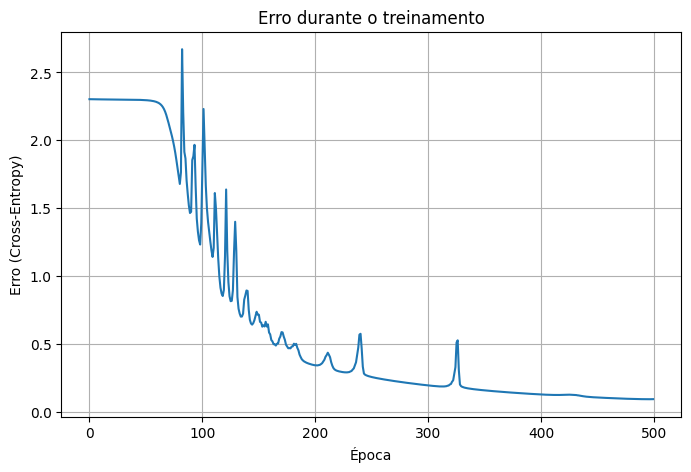

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(historico_erro)

plt.title("Erro durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Erro (Cross-Entropy)")
plt.grid(True)

plt.show()

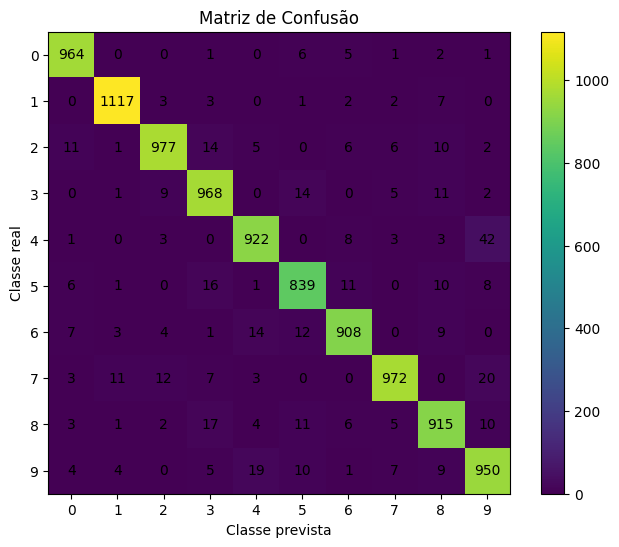

In [20]:
matriz_confusao = np.zeros((10, 10), dtype=int)

for real, previsto in zip(y_teste, previsoes_teste):
    matriz_confusao[real][previsto] += 1

plt.figure(figsize=(8, 6))
plt.imshow(matriz_confusao)

plt.title("Matriz de Confusão")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.xticks(range(10))
plt.yticks(range(10))

plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, matriz_confusao[i][j], ha="center", va="center")

plt.show()

In [21]:
precisao = []
recall = []
f1_score = []

for classe in range(10):
    verdadeiro_positivo = matriz_confusao[classe][classe]

    total_previsto_como_classe = np.sum(matriz_confusao[:, classe])
    total_real_da_classe = np.sum(matriz_confusao[classe, :])

    p = verdadeiro_positivo / total_previsto_como_classe
    r = verdadeiro_positivo / total_real_da_classe
    f1 = 2 * p * r / (p + r)

    precisao.append(p)
    recall.append(r)
    f1_score.append(f1)

print("Classe | Precisão | Recall | F1-score")
for classe in range(10):
    print(
        classe,
        "|",
        round(precisao[classe], 4),
        "|",
        round(recall[classe], 4),
        "|",
        round(f1_score[classe], 4)
    )

Classe | Precisão | Recall | F1-score
0 | 0.965 | 0.9837 | 0.9742
1 | 0.9807 | 0.9841 | 0.9824
2 | 0.9673 | 0.9467 | 0.9569
3 | 0.938 | 0.9584 | 0.9481
4 | 0.9525 | 0.9389 | 0.9456
5 | 0.9395 | 0.9406 | 0.9401
6 | 0.9588 | 0.9478 | 0.9533
7 | 0.971 | 0.9455 | 0.9581
8 | 0.9375 | 0.9394 | 0.9385
9 | 0.9179 | 0.9415 | 0.9295


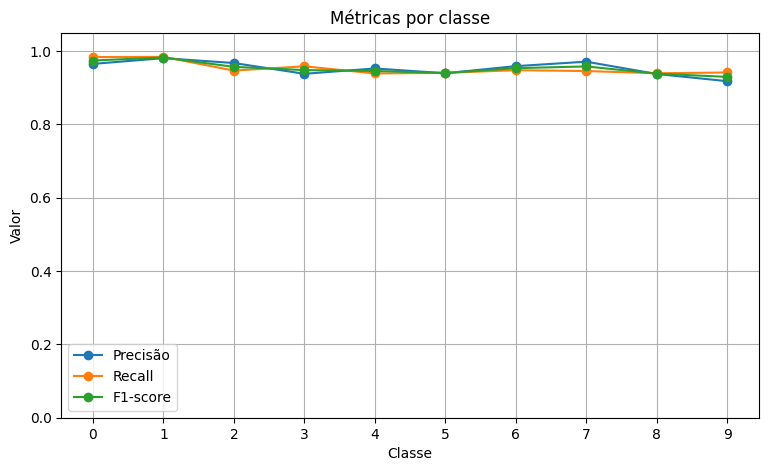

In [22]:
classes = np.arange(10)

plt.figure(figsize=(9, 5))

plt.plot(classes, precisao, marker="o", label="Precisão")
plt.plot(classes, recall, marker="o", label="Recall")
plt.plot(classes, f1_score, marker="o", label="F1-score")

plt.title("Métricas por classe")
plt.xlabel("Classe")
plt.ylabel("Valor")
plt.xticks(classes)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

plt.show()

## Conclusão

Neste trabalho foi implementada uma rede neural simples para classificar imagens do conjunto MNIST. As imagens foram transformadas de matrizes 28x28 para vetores de 784 posições e seus valores foram normalizados para o intervalo de 0 a 1, facilitando o treinamento da rede.

A versão final utilizou 15.000 imagens do conjunto de treino, 500 épocas e taxa de aprendizado igual a 0.5. Com esses parâmetros, o modelo obteve acurácia de aproximadamente 97,46% no conjunto usado para treino e 95,32% no conjunto de teste.

A diferença entre a acurácia de treino e teste mostra que a rede conseguiu aprender bem os padrões dos dados sem perder muito desempenho em dados não vistos. Mesmo assim, o gráfico do erro mostra algumas oscilações durante o treinamento, provavelmente causadas pela taxa de aprendizado relativamente alta.

A matriz de confusão mostra que a maior parte das imagens foi classificada corretamente, com os maiores valores concentrados na diagonal principal. Os erros aparecem principalmente entre dígitos visualmente parecidos, como 4 e 9, 3 e 5, ou 8 e 9.

Como melhoria futura, seria possível testar outros valores de taxa de aprendizado, usar mais dados de treino, alterar a quantidade de neurônios da camada oculta ou implementar técnicas mais avançadas, como redes neurais convolucionais, que são mais adequadas para problemas envolvendo imagens.